# NEWS CATEGORY CLASSIFICATION

#### DATASET DOWNLOADING

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rmisra/news-category-dataset")

print("Path to dataset files:", path)

p:\PROJECTS\DATA SCIENCE\NEWS CATEGORY CLASSIFICATION\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\khage\.cache\kagglehub\datasets\rmisra\news-category-dataset\versions\3


#### DATASET LOADING

In [2]:
import pandas as pd
import json

path+="/News_Category_Dataset_v3.json"
df = pd.read_json(path, lines=True)

#### DATA INSPECTION

GETTING SHAPE OF THE DATASET

In [3]:
df.shape

(209527, 6)

DISPLAYING FIRST 5 RECORDS


In [4]:
df.head()

,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22


GETTING HOW MANY RECORDS ARE THERE IN EACH CATEGORY

In [5]:
print(df['category'].value_counts())

category
POLITICS          35602
WELLNESS          17945
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9814
PARENTING          8791
HEALTHY LIVING     6694
QUEER VOICES       6347
FOOD & DRINK       6340
BUSINESS           5992
COMEDY             5400
SPORTS             5077
BLACK VOICES       4583
HOME & LIVING      4320
PARENTS            3955
THE WORLDPOST      3664
WEDDINGS           3653
WOMEN              3572
CRIME              3562
IMPACT             3484
DIVORCE            3426
WORLD NEWS         3299
MEDIA              2944
WEIRD NEWS         2777
GREEN              2622
WORLDPOST          2579
RELIGION           2577
STYLE              2254
SCIENCE            2206
TECH               2104
TASTE              2096
MONEY              1756
ARTS               1509
ENVIRONMENT        1444
FIFTY              1401
GOOD NEWS          1398
U.S. NEWS          1377
ARTS & CULTURE     1339
COLLEGE            1144
LATINO VOICES      1130
CULTURE & ARTS     1074
EDUCATI

GETTING TOTAL RECORDS AND CATEGORY COUNTS

In [6]:
print(f"Total records: {len(df)}")
print(f"Categories: {df['category'].nunique()}")

Total records: 209527
Categories: 42


#### DATA CLEANING

CHECKING NULL OCCURANCES

In [7]:
df.isnull().sum()

link                 0
headline             0
category             0
short_description    0
authors              0
date                 0
dtype: int64

CHECKING DUPLICATE VALUES

In [8]:
print(df.duplicated().sum())
dupRow = df[df.duplicated()]
print(dupRow)

13
                                                     link  \
67677   https://www.huffingtonpost.comhttp://www.mothe...   
67923   https://www.huffingtonpost.comhttp://gizmodo.c...   
70239   https://www.huffingtonpost.comhttp://www.cnbc....   
139830  https://www.huffingtonpost.comhttp://www.cnn.c...   
144409  https://www.huffingtonpost.comhttp://www.upwor...   
145142  https://www.huffingtonpost.comhttp://www.weath...   
178155  https://www.huffingtonpost.comhttp://www.busin...   
187329  https://www.huffingtonpost.comhttp://www.nytim...   
194596  https://www.huffingtonpost.comhttp://blogs.wsj...   
194598  https://www.huffingtonpost.comhttp://www.theda...   
207122  https://www.huffingtonpost.comhttp://d.repubbl...   
207208  https://www.huffingtonpost.comhttp://d.repubbl...   
207318  https://www.huffingtonpost.comhttp://d.repubbl...   

                                                 headline        category  \
67677   On Facebook, Trump's Longtime Butler Calls For...        

REMOVING DUPLICATE VALUES

In [9]:
df = df.drop_duplicates()

CREATING NEW COLUMN AS "text" FOR BOTH HEADLINE AND DESCRIPTION

In [10]:
df['text'] = df['headline'] + ' ' + df['short_description']

REMOVING EMPTY TEXT

In [11]:
df = df[df['text'].str.strip() != ""]

REMOVING COLUMS THAT ARE NOT REQUIRED

In [12]:
df.drop(columns=['link','short_description','headline','authors'], inplace=True)

#### DATA PREPROCESSING

IMPORT STOPWORDS AND LEMMATIZER FROM NLTK

In [13]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re
import nltk

DOWNLOAD THE WORDNET AND STOPWORDS

In [14]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\khage\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\khage\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

INIITIALIZE THE VARIABLES

In [15]:
stopwords = set(stopwords.words('english')) 
lemmatizer = WordNetLemmatizer()

PREPROCESS TEXT FUNCTION

In [16]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stopwords]
    return ' '.join(words)
        

APPLY THE FUNCTION

In [17]:
df['text'] = df['text'].apply(preprocess_text)

In [18]:
df.head()

,category,date,text
0,U.S. NEWS,2022-09-23,million american roll sleeve omicrontargeted c...
1,U.S. NEWS,2022-09-23,american airline flyer charged banned life pun...
2,COMEDY,2022-09-23,funniest tweet cat dog week sept dog dont unde...
3,PARENTING,2022-09-23,funniest tweet parent week sept accidentally p...
4,U.S. NEWS,2022-09-22,woman called cop black birdwatcher loses lawsu...


#### EDA (EXPLORATORY DATA ANALYSIS)

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

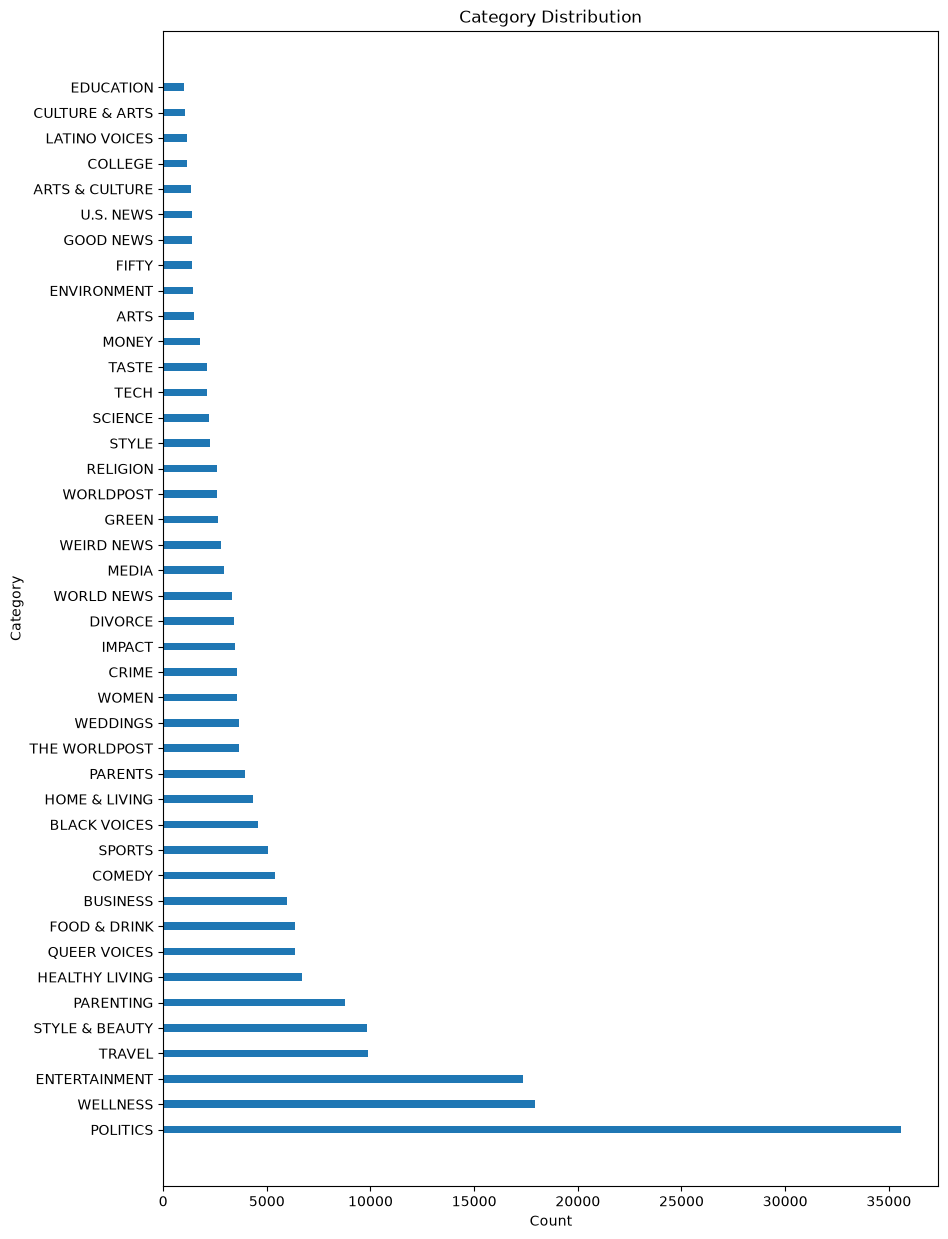

In [20]:
plt.figure(figsize=(10,15))
plt.barh(df['category'].value_counts().index, df['category'].value_counts().values,height=0.3)
plt.ylabel('Category')
plt.xlabel('Count')
plt.title('Category Distribution')
plt.show()


In [21]:
df['date'].dt.year.value_counts()

date
2013    34580
2014    32337
2016    32095
2015    32002
2012    31349
2017    29889
2018     9734
2021     2066
2020     2054
2019     2005
2022     1398
Name: count, dtype: int64

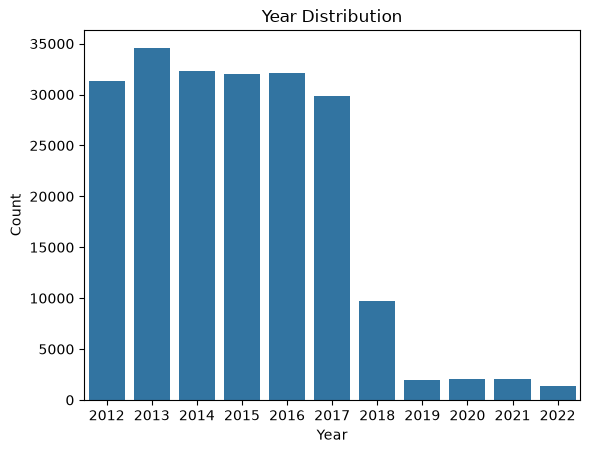

In [22]:
sns.countplot(x=df['date'].dt.year)
plt.xlabel('Year')
plt.ylabel('Count')
plt.title('Year Distribution')
plt.show()

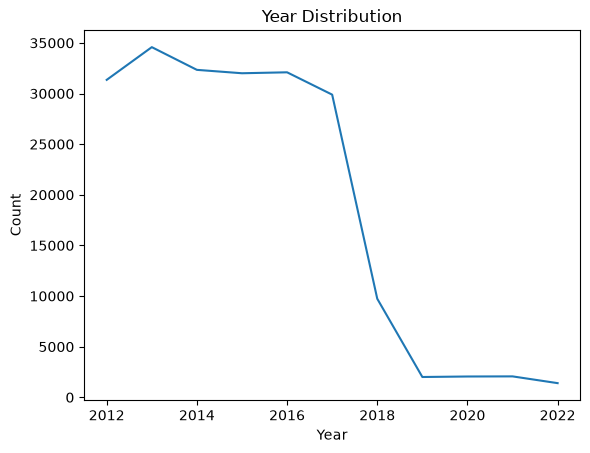

In [23]:
dt_arr=df['date'].dt.year.value_counts()
# The data we get from the value_count is sorted accoring to the value , we need it to sort that according to index.
xs,ys=zip(*sorted(zip(dt_arr.index,dt_arr.values)))
plt.plot(xs,ys)
plt.xlabel('Year')
plt.ylabel('Count')
plt.title('Year Distribution')
plt.show()

<Axes: >

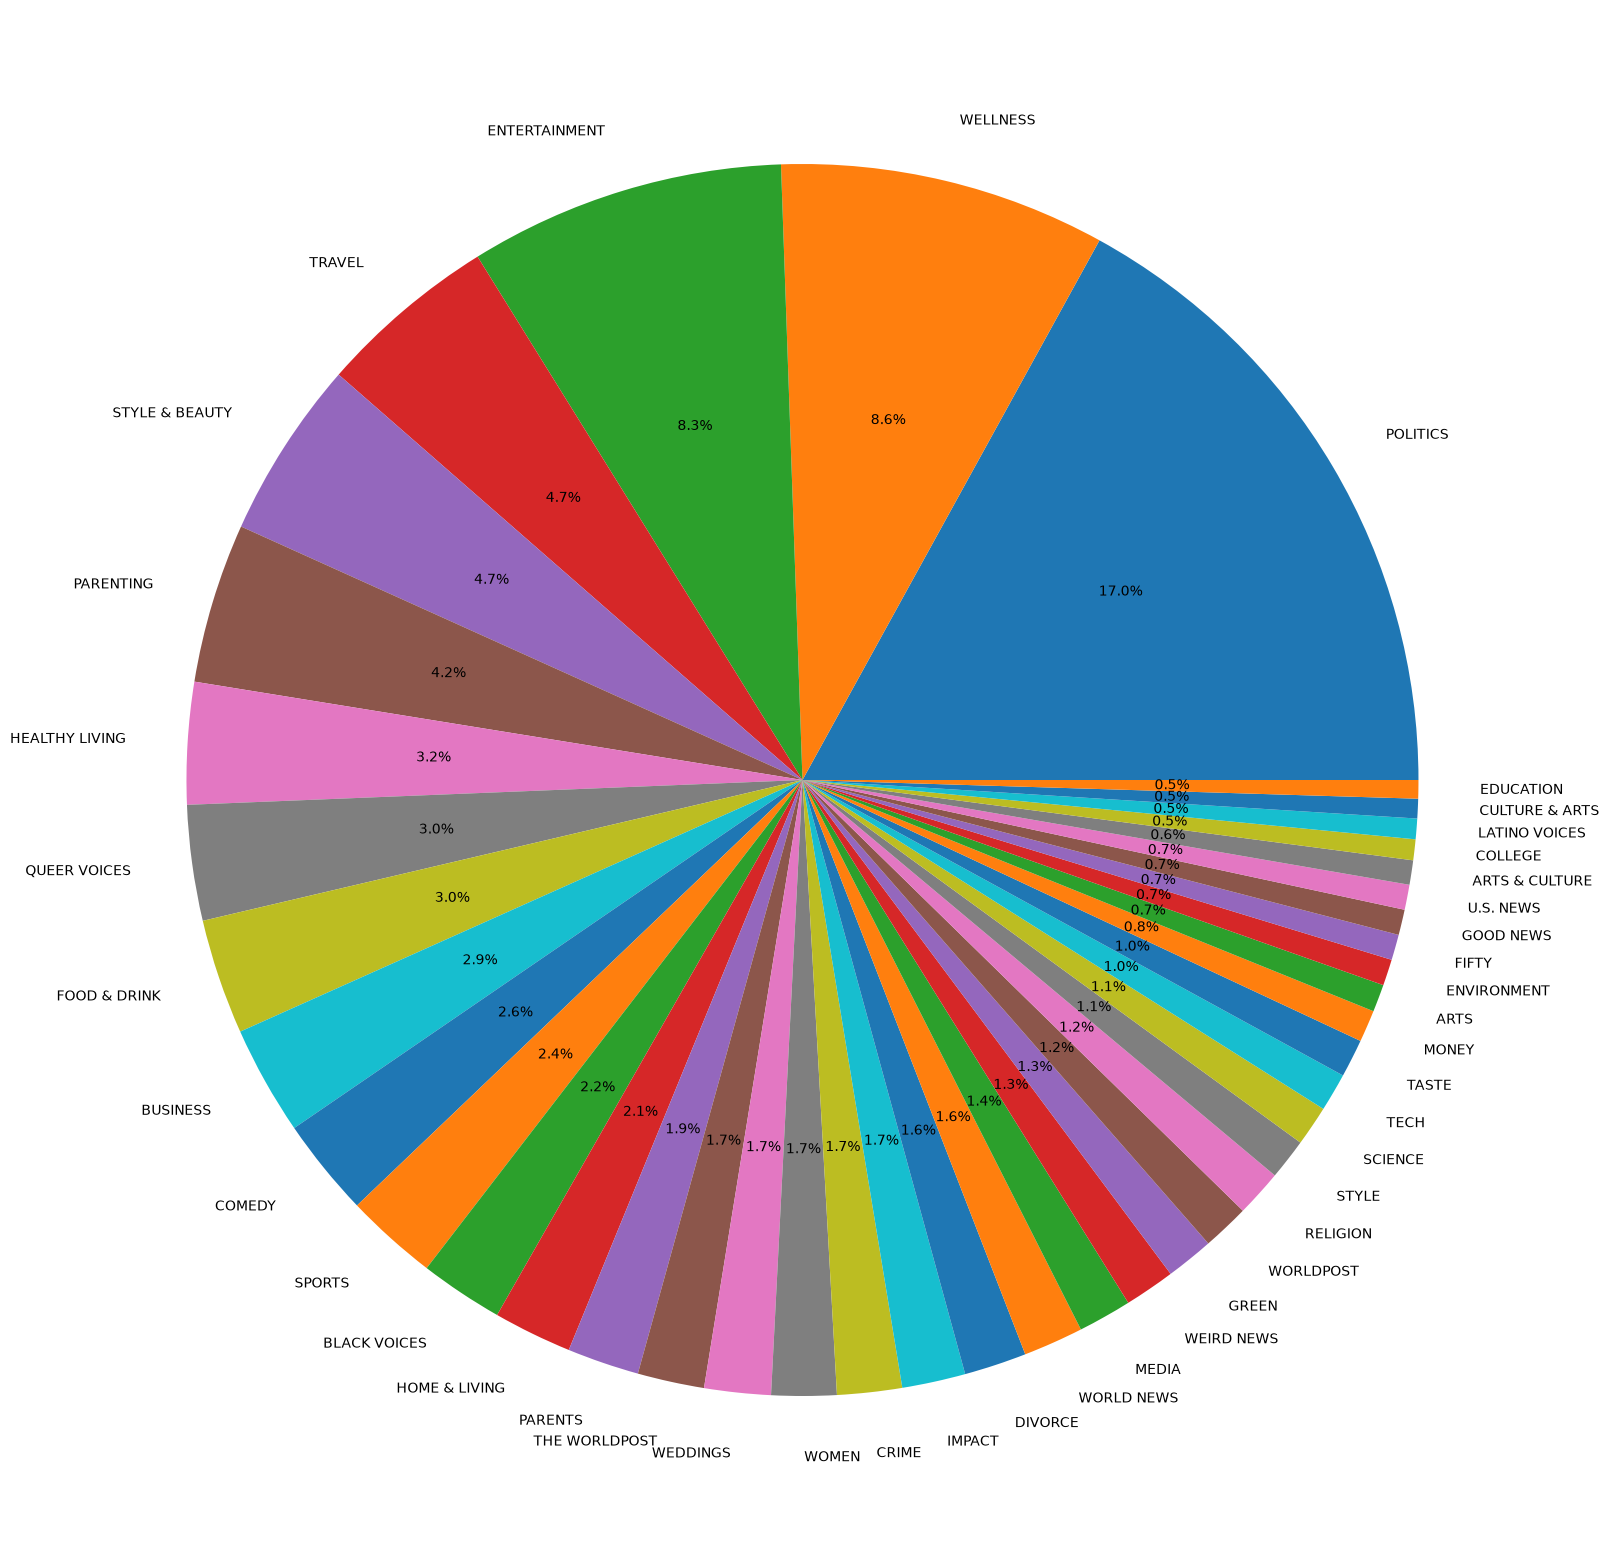

In [24]:
df['category'].value_counts().plot(kind='pie', figsize=(20,20), autopct='%1.1f%%',)

<Axes: >

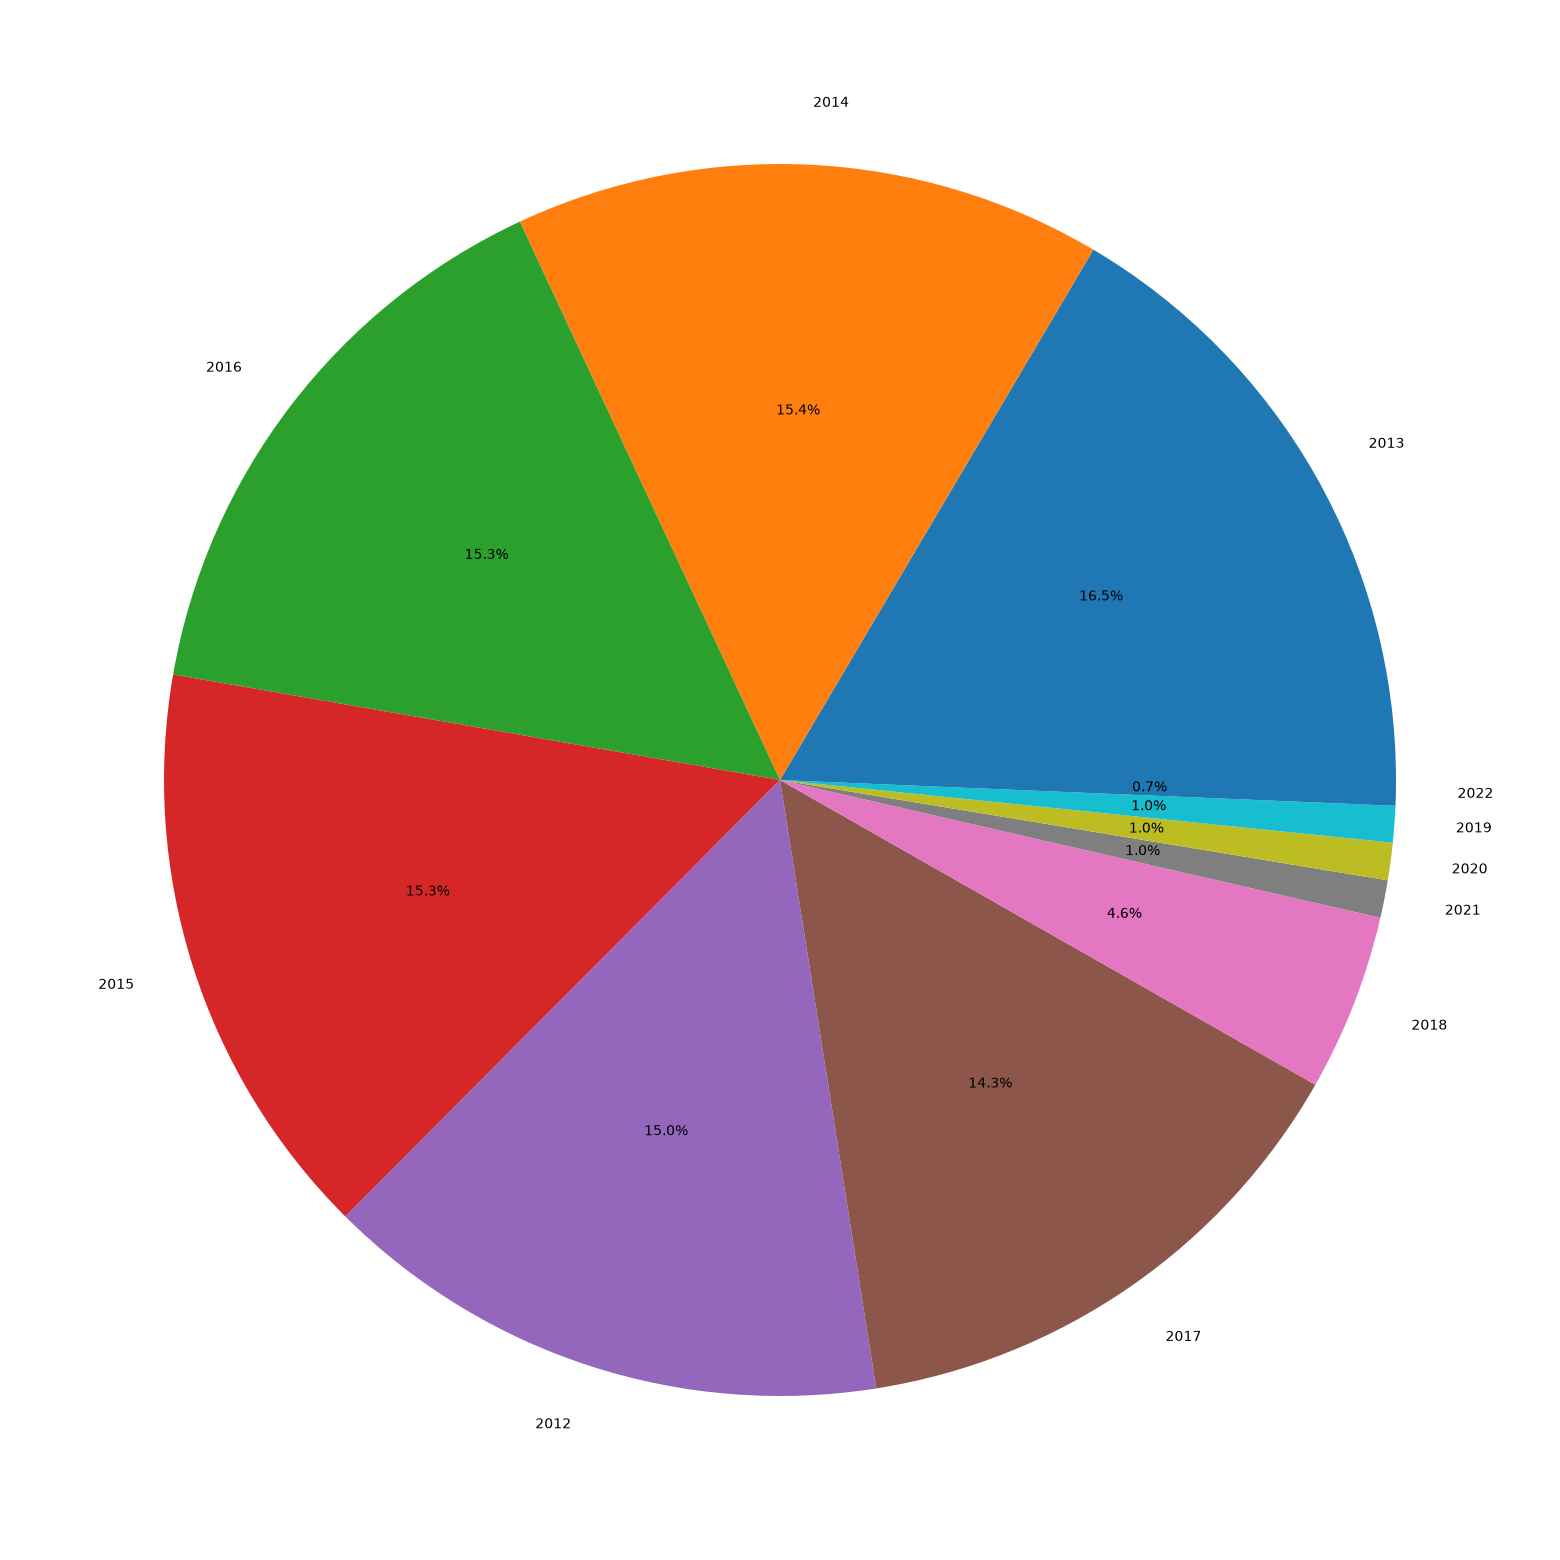

In [25]:
df['date'].dt.year.value_counts().plot(kind='pie', figsize=(20,20), autopct='%1.1f%%',)

In [26]:
pd.crosstab(df['category'], df['date'].dt.year)

date,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
category,,,,,,,,,,,
ARTS,0,0,801,618,87,3,0,0,0,0,0
ARTS & CULTURE,0,0,0,207,596,523,13,0,0,0,0
BLACK VOICES,307,320,424,958,1150,961,418,23,13,5,4
BUSINESS,679,846,1448,1535,936,406,92,7,18,9,15
COLLEGE,0,0,380,524,182,57,1,0,0,0,0
COMEDY,604,487,690,811,989,1151,513,105,13,22,15
CRIME,199,236,548,997,802,449,200,35,17,41,38
CULTURE & ARTS,343,558,129,0,0,0,2,4,12,3,23
DIVORCE,1256,1772,398,0,0,0,0,0,0,0,0


<Axes: xlabel='date', ylabel='category'>

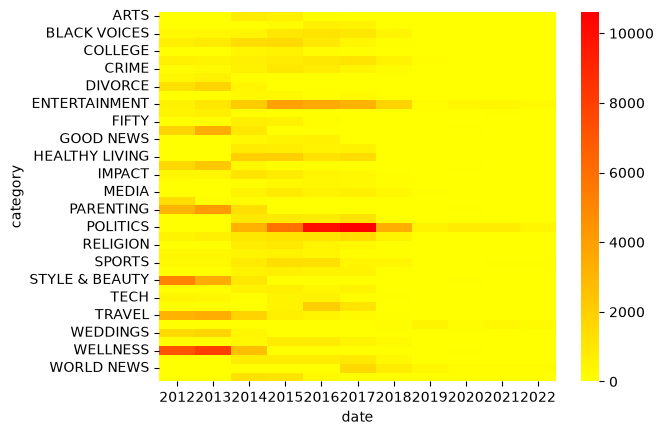

In [27]:
sns.heatmap(pd.crosstab(df['category'],df['date'].dt.year), cmap='autumn_r')

In [28]:
df['category'].value_counts()/len(df)*100

category
POLITICS          16.992110
WELLNESS           8.563833
ENTERTAINMENT      8.286995
TRAVEL             4.725334
STYLE & BEAUTY     4.682854
PARENTING          4.196001
HEALTHY LIVING     3.195089
QUEER VOICES       3.028987
FOOD & DRINK       3.026123
BUSINESS           2.859543
COMEDY             2.577455
SPORTS             2.423285
BLACK VOICES       2.187496
HOME & LIVING      2.061964
PARENTS            1.887747
THE WORLDPOST      1.748851
WEDDINGS           1.743601
WOMEN              1.704461
CRIME              1.700166
IMPACT             1.662936
DIVORCE            1.635252
WORLD NEWS         1.574634
MEDIA              1.404713
WEIRD NEWS         1.325480
GREEN              1.251498
WORLDPOST          1.230496
RELIGION           1.230019
STYLE              1.075849
SCIENCE            1.052938
TECH               1.002344
TASTE              1.000434
MONEY              0.838150
ARTS               0.720255
ENVIRONMENT        0.688753
FIFTY              0.668706
GOOD NEWS  